# Análisis exploratorio de imágenes de palta Hass
**Autor:** Luis Daniel Paliza Vilca · **Modelo futuro:** ResNet50 mediante Transfer Learning.

Objetivo: auditar los datos antes de entrenar. No se eliminan, mueven ni sobrescriben imágenes. Cada archivo representa una palta completa con tres franjas de cámaras, según la documentación del proyecto; las vistas de una misma fruta no son observaciones independientes.

Ejecute todas las celdas en orden. Los resultados se calculan nuevamente con los archivos disponibles. La guía de Semana 2 se utiliza como antecedente para reproducibilidad, particiones y prevención de fuga de información. No se entrena ningún modelo.

In [1]:
from pathlib import Path
from itertools import combinations
from collections import Counter
import hashlib
import json
import platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display, Markdown

SEMILLA = 42
UMBRAL_DHASH = 4  # Distancia Hamming sobre 64 bits: candidatos, no prueba de identidad.
PARTICIONES = ['train', 'validation', 'test']
EXTENSIONES = {'.tif', '.tiff', '.png', '.jpg', '.jpeg', '.bmp', '.webp', '.gif'}
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.2})
pd.set_option('display.max_columns', 25)

# Encuentra la raíz desde la carpeta del notebook o desde el repositorio.
RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'README.md').is_file() and (p / '4. entrenamiento').is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError('Ejecute desde la raíz del repositorio o 4. entrenamiento.')
# Puede definir una ruta relativa explícita si dispone de varias copias.
RUTA_DATASET_MANUAL = None
candidatas = [RAIZ / 'DATASET_PALTA', RAIZ.parent / 'DATASET_PALTA']
disponibles = [p for p in candidatas if p.is_dir()]
if RUTA_DATASET_MANUAL is not None:
    DATASET = (RAIZ / RUTA_DATASET_MANUAL).resolve()
elif len(disponibles) == 1:
    DATASET = disponibles[0]
else:
    raise FileNotFoundError('Debe existir una única DATASET_PALTA dentro o junto al repositorio; defina RUTA_DATASET_MANUAL si hay ambigüedad.')
if not all((DATASET / p).is_dir() for p in PARTICIONES):
    raise ValueError('Falta alguna partición train/validation/test. No se crearán particiones automáticamente.')
import os
RUTA_RELATIVA = Path(os.path.relpath(DATASET, RAIZ)).as_posix()
SALIDA = RAIZ / '4. entrenamiento'
versiones = {p: importlib.metadata.version(p) for p in ['numpy','pandas','matplotlib','Pillow','nbformat','nbclient','ipykernel']}
print('Dataset relativo al repositorio:', RUTA_RELATIVA)
print('Python:', platform.python_version(), '| Semilla:', SEMILLA)
display(pd.Series(versiones, name='Versión'))

Dataset relativo al repositorio: ../DATASET_PALTA
Python: 3.12.14 | Semilla: 42


numpy          2.5.3
pandas         3.0.6
matplotlib    3.11.2
Pillow        12.3.0
nbformat      5.11.1
nbclient      0.11.0
ipykernel      7.4.0
Name: Versión, dtype: str

## 1. Inventario, calidad y características
Se enumeran todos los archivos, incluidos los no reconocidos como imágenes. Se verifica el archivo y se decodifican todas sus páginas. Las estadísticas visuales y los hashes de píxeles corresponden a la primera página orientada según EXIF; los archivos multipágina se reportan para revisión.

SHA-256 compara bytes del archivo. Otro SHA-256 compara dimensiones y píxeles RGB decodificados, lo que permite detectar imágenes iguales con metadatos diferentes. dHash compara gradientes de una miniatura en escala de grises: sirve para proponer coincidencias visuales, puede tener falsos positivos y falsos negativos.

RGB e intensidad se calculan sobre todos los píxeles, incluido el fondo. El brillo es la aproximación 0,299R + 0,587G + 0,114B, en escala 0–255, no una medición fotométrica. Las conversiones ocurren únicamente en memoria.

In [2]:
def hash_archivo(ruta):
    h = hashlib.sha256()
    with ruta.open('rb') as f:
        for bloque in iter(lambda: f.read(1024 * 1024), b''):
            h.update(bloque)
    return h.hexdigest()

def hash_perceptual(imagen):
    miniatura = np.asarray(imagen.convert('L').resize((9, 8), Image.Resampling.LANCZOS))
    bits = (miniatura[:, 1:] > miniatura[:, :-1]).ravel()
    return int.from_bytes(np.packbits(bits).tobytes(), 'big')

def inspeccionar(ruta):
    partes = ruta.relative_to(DATASET).parts
    r = dict(archivo=ruta.relative_to(DATASET).as_posix(),
             particion=partes[0] if partes[0] in PARTICIONES else 'fuera_particion',
             clase=partes[1] if len(partes) >= 3 and partes[0] in PARTICIONES else 'sin_clase',
             extension=ruta.suffix.lower(), bytes=ruta.stat().st_size,
             imagen=ruta.suffix.lower() in EXTENSIONES, error='')
    r['sha256'] = hash_archivo(ruta)
    if not r['imagen']:
        return r
    try:
        with Image.open(ruta) as im:
            im.verify()
        with Image.open(ruta) as im:
            r.update(ancho=im.width, alto=im.height, canales=len(im.getbands()),
                     modo=im.mode, formato=im.format, paginas=getattr(im, 'n_frames', 1))
            for pagina in range(r['paginas']):
                im.seek(pagina)
                im.load()
            im.seek(0)
            rgb = ImageOps.exif_transpose(im).convert('RGB')
            matriz = np.asarray(rgb)
            medias = matriz.mean(axis=(0, 1), dtype=np.float64)
            r.update(resolucion=im.width * im.height, aspecto=im.width / im.height,
                     rojo=float(medias[0]), verde=float(medias[1]), azul=float(medias[2]),
                     intensidad=float(medias.mean()), brillo=float(medias @ [0.299, 0.587, 0.114]),
                     sha_pixeles=hashlib.sha256(str(rgb.size).encode() + matriz.tobytes()).hexdigest(),
                     dhash=f'{hash_perceptual(rgb):016x}')
    except Exception as exc:
        r['error'] = f'{type(exc).__name__}: {exc}'
    return r

archivos = sorted(p for p in DATASET.rglob('*') if p.is_file())
if not archivos:
    raise ValueError('Dataset vacío.')
registros = []
for i, ruta in enumerate(archivos, 1):
    registros.append(inspeccionar(ruta))
    if i % 100 == 0:
        print(f'Inspeccionados {i}/{len(archivos)} archivos')
inventario = pd.DataFrame(registros)
imagenes = inventario[inventario.imagen].copy()
validas = imagenes[imagenes.error.eq('')].copy()
if validas.empty:
    raise ValueError('No hay imágenes legibles; revise las rutas y formatos.')
print(f'Archivos: {len(inventario)}; imágenes por extensión: {len(imagenes)}; legibles: {len(validas)}')
display(inventario.head())

Inspeccionados 100/829 archivos


Inspeccionados 200/829 archivos


Inspeccionados 300/829 archivos


Inspeccionados 400/829 archivos


Inspeccionados 500/829 archivos


Inspeccionados 600/829 archivos


Inspeccionados 700/829 archivos


Inspeccionados 800/829 archivos


Archivos: 829; imágenes por extensión: 829; legibles: 829


,archivo,particion,clase,extension,bytes,imagen,error,sha256,ancho,alto,canales,modo,formato,paginas,resolucion,aspecto,rojo,verde,azul,intensidad,brillo,sha_pixeles,dhash
0,test/PICADURA/704F3E54-260519-164003-3.RGB.tiff,test,PICADURA,.tiff,2531914,True,,81009a16da3c41ab16c2aa0e1414d0f2cb566599a5ebc7...,2131,885,3,RGB,TIFF,1,1885935,2.407910,39.978846,38.967537,34.512473,37.819619,38.762041,9bc9595a160ea837593c0ecb1e43f2463dee1de7f913e3...,31fce40474d00cd8
1,test/PICADURA/704F3E54-260519-164006-2.RGB.tiff,test,PICADURA,.tiff,1627328,True,,e72a8d8f27440582beeeb52a319f2432885af658d039f9...,1814,723,3,RGB,TIFF,1,1311522,2.508990,31.882459,30.259959,26.981938,29.708119,30.371392,0b7703b8e892f507fba2b0c8ba5ff8bcea64a64f76f1f5...,e0c6cef830f84430
2,test/PICADURA/704F3E54-260519-164008-2.RGB.tiff,test,PICADURA,.tiff,1800930,True,,22065b864089cffb128b82435c93d3bf7da0728651c957...,1929,739,3,RGB,TIFF,1,1425531,2.610284,29.824079,28.552511,24.748952,27.708514,28.499104,1b3ae562f7ec133bb9fe1a8d720493f61eb53edbc66a54...,2078f870f0da7870
3,test/PICADURA/704F3E54-260519-164010-6.RGB.tiff,test,PICADURA,.tiff,2567172,True,,9ded076fce259c98ee4aa24a3534406e44bb9524c54f53...,2269,871,3,RGB,TIFF,1,1976299,2.605052,36.804293,36.202736,31.727306,34.911445,35.872403,9713267dbfcc87cd9867e14e24f63ea9e4327c5d2cb063...,c6ec8c1931314428
4,test/PICADURA/704F3E54-260519-164018-1.RGB.tiff,test,PICADURA,.tiff,2078112,True,,5333da4ae70006e5ba2c38e498f2db23390e93af73e6c8...,1993,828,3,RGB,TIFF,1,1650204,2.407005,35.333975,34.621126,29.442294,33.132465,34.243881,63effd5fcb440db1fc2301f6e65c7061e894eee6df9447...,05364664a0063600


## 2. Clases, particiones y desbalance
Los conteos incluyen archivos con extensión de imagen, aunque puedan estar dañados; la calidad se reporta por separado. Se muestran también clases vacías si sus carpetas existen. La razón mayoritaria/minoritaria cuantifica el desbalance; los niveles descriptivos usados aquí (≤1,5 leve, ≤3 moderado, >3 marcado) son convenciones de este informe, no umbrales universales.

clase,PICADURA,RUSSET,Total,Porcentaje
particion,,,,
train,497,77,574,69.24
validation,107,21,128,15.44
test,106,21,127,15.32


,Imágenes,Porcentaje
clase,,
PICADURA,710,85.65
RUSSET,119,14.35


,Razón máx/mín
particion,
train,6.454545
validation,5.095238
test,5.047619


Mayoritaria: PICADURA; minoritaria: RUSSET; razón: 5.97:1 (marcado).


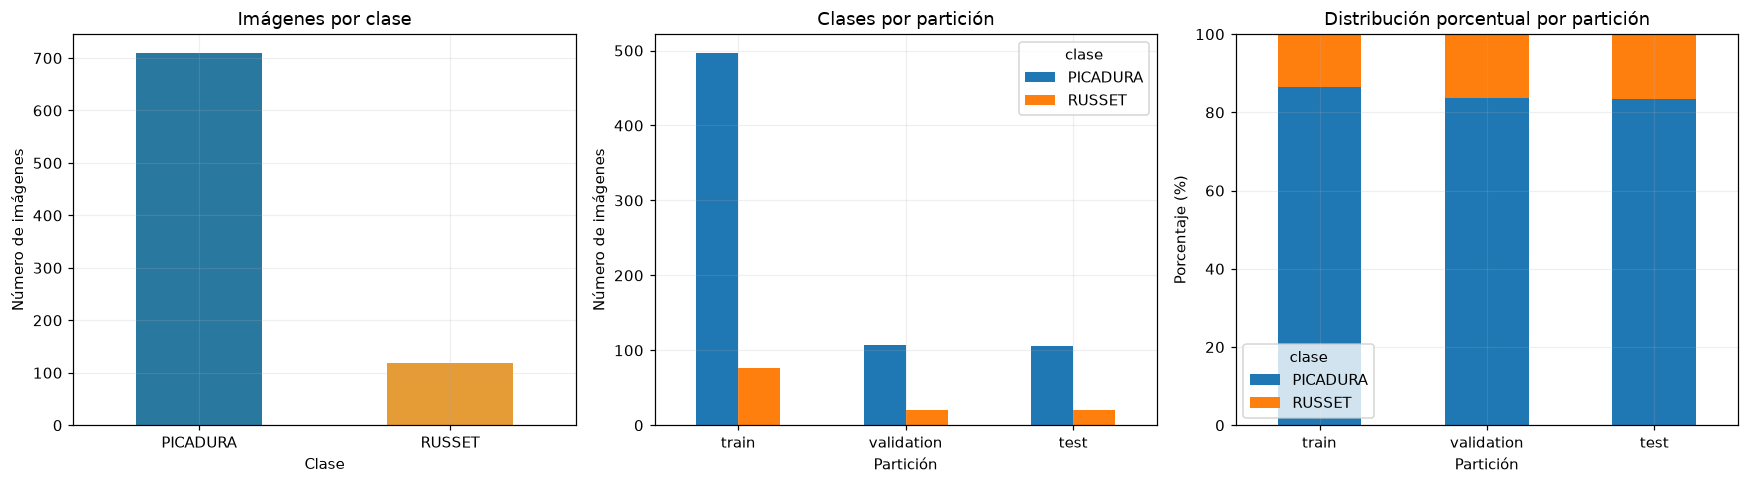

In [3]:
clases = sorted({p.name for s in PARTICIONES for p in (DATASET / s).iterdir() if p.is_dir()})
conteos = pd.crosstab(imagenes.particion, imagenes.clase).reindex(index=PARTICIONES, columns=clases, fill_value=0)
resumen = conteos.copy()
resumen['Total'] = conteos.sum(axis=1)
resumen['Porcentaje'] = resumen.Total / len(imagenes) * 100
por_clase = conteos.sum().sort_values(ascending=False)
tabla_clases = pd.DataFrame({'Imágenes': por_clase, 'Porcentaje': por_clase / len(imagenes) * 100})
razon = float(por_clase.max() / por_clase.min()) if por_clase.min() else float('inf')
grado = 'leve' if razon <= 1.5 else 'moderado' if razon <= 3 else 'marcado'
display(resumen.round(2)); display(tabla_clases.round(2))
display(pd.DataFrame({'Razón máx/mín': conteos.max(axis=1) / conteos.min(axis=1).replace(0, np.nan)}))
print(f'Mayoritaria: {por_clase.idxmax()}; minoritaria: {por_clase.idxmin()}; razón: {razon:.2f}:1 ({grado}).')
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
por_clase.plot.bar(ax=axs[0], color=['#2878a0', '#e59b36'])
axs[0].set(title='Imágenes por clase', xlabel='Clase', ylabel='Número de imágenes')
conteos.plot.bar(ax=axs[1]); axs[1].set(title='Clases por partición', xlabel='Partición', ylabel='Número de imágenes')
proporciones = conteos.div(conteos.sum(axis=1), axis=0) * 100
proporciones.plot.bar(stacked=True, ax=axs[2]); axs[2].set(title='Distribución porcentual por partición', xlabel='Partición', ylabel='Porcentaje (%)', ylim=(0, 100))
for ax in axs: ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 3. Dimensiones, canales y formatos
Resolución = ancho × alto, en píxeles. Se informan estadísticas descriptivas con desviación estándar muestral. Una resolución atípica se marca mediante 1,5 × IQR en ancho, alto o aspecto; si IQR = 0, se marca cualquier valor distinto de la mediana. Es una señal de revisión, no un diagnóstico de error.

,min,max,mean,median,std
ancho,1434.000000,2.429000e+03,1.952228e+03,1.949000e+03,156.613003
alto,577.000000,1.068000e+03,7.835440e+02,7.800000e+02,69.450167
resolucion,864923.000000,2.437176e+06,1.537564e+06,1.523522e+06,242103.326300
aspecto,2.024775,3.454942e+00,2.497947e+00,2.499373e+00,0.154469
canales,3.000000,3.000000e+00,3.000000e+00,3.000000e+00,0.000000


,formato,extension,modo,canales,paginas,Cantidad
0,TIFF,.tiff,RGB,3,1,829


,ancho,alto,Cantidad
0,1788,744,2
1,1865,759,2
2,1874,713,2
3,1744,735,2
4,1807,727,2
...,...,...,...
817,2377,688,1
818,2383,927,1
819,2405,911,1
820,2409,999,1


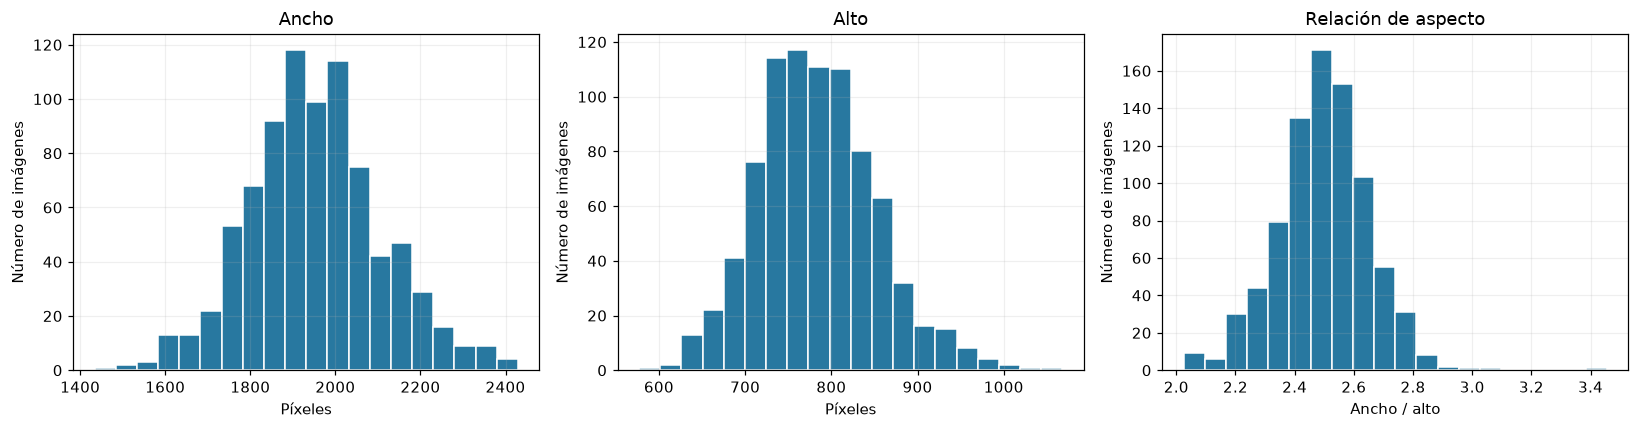

,archivo,clase,particion,motivo
0,test/PICADURA/704F3E54-260519-164241-2.RGB.tiff,PICADURA,test,Resolución/aspecto atípico
1,test/PICADURA/704F3E54-260520-113424-5.RGB.tiff,PICADURA,test,Resolución/aspecto atípico
2,test/PICADURA/704F3E54-260520-113651-5.RGB.tiff,PICADURA,test,Resolución/aspecto atípico
3,test/RUSSET/704F3E54-250624-140134-4.RGB.tiff,RUSSET,test,Resolución/aspecto atípico
4,train/PICADURA/704F3E54-250626-152149-9.RGB.tiff,PICADURA,train,Resolución/aspecto atípico
5,train/PICADURA/704F3E54-250626-152153-5.RGB.tiff,PICADURA,train,Resolución/aspecto atípico
6,train/PICADURA/704F3E54-250704-112258-1.RGB.tiff,PICADURA,train,Resolución/aspecto atípico
7,train/PICADURA/704F3E54-250819-153400-6.RGB.tiff,PICADURA,train,Resolución/aspecto atípico
8,train/PICADURA/704F3E54-260519-145444-3.RGB.tiff,PICADURA,train,Resolución/aspecto atípico
9,train/PICADURA/704F3E54-260519-145524-4.RGB.tiff,PICADURA,train,Resolución/aspecto atípico


Incidencias: 37 | Archivos afectados: 37


In [4]:
columnas = ['ancho','alto','resolucion','aspecto','canales']
estadisticas = validas[columnas].agg(['min','max','mean','median','std']).T
display(estadisticas)
display(validas.groupby(['formato','extension','modo','canales','paginas']).size().rename('Cantidad').reset_index())
display(validas.groupby(['ancho','alto']).size().sort_values(ascending=False).rename('Cantidad').reset_index())
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo, unidad in zip(axs, ['ancho','alto','aspecto'], ['Ancho','Alto','Relación de aspecto'], ['Píxeles','Píxeles','Ancho / alto']):
    ax.hist(validas[col], bins=20, color='#2878a0', edgecolor='white')
    ax.set(title=titulo, xlabel=unidad, ylabel='Número de imágenes')
plt.tight_layout(); plt.show()

def atipicos(serie):
    q1, q3 = serie.quantile([0.25, 0.75]); iqr = q3 - q1
    return serie.ne(serie.median()) if iqr == 0 else (serie < q1 - 1.5*iqr) | (serie > q3 + 1.5*iqr)

validas['resolucion_atipica'] = atipicos(validas.ancho) | atipicos(validas.alto) | atipicos(validas.aspecto)
problemas = []
for r in inventario.to_dict('records'):
    motivos = []
    if not r['imagen']: motivos.append('Archivo no reconocido como imagen por extensión')
    if r['error']: motivos.append('Error de apertura/verificación: ' + r['error'])
    if r['particion'] not in PARTICIONES or r['clase'] == 'sin_clase': motivos.append('Fuera de estructura esperada')
    if r['imagen'] and not r['error']:
        if r['modo'] != 'RGB' or r['canales'] != 3: motivos.append('Modo/canales distintos de RGB de 3 canales')
        if r['paginas'] != 1: motivos.append('Imagen multipágina: características calculadas en primera página')
        if r['formato'] != validas.formato.mode().iloc[0]: motivos.append('Formato distinto del predominante')
        extensiones_formato = {'.tif':'TIFF','.tiff':'TIFF','.jpg':'JPEG','.jpeg':'JPEG','.png':'PNG','.bmp':'BMP','.webp':'WEBP','.gif':'GIF'}
        if extensiones_formato.get(r['extension']) != r['formato']: motivos.append('Extensión y formato no coinciden')
        if bool(validas.loc[validas.archivo.eq(r['archivo']), 'resolucion_atipica'].iloc[0]): motivos.append('Resolución/aspecto atípico')
    for motivo in motivos:
        problemas.append({k:r[k] for k in ['archivo','clase','particion']} | {'motivo':motivo})
calidad = pd.DataFrame(problemas, columns=['archivo','clase','particion','motivo'])
display(calidad.head(30)); print('Incidencias:', len(calidad), '| Archivos afectados:', calidad.archivo.nunique())

## 4. Muestras reales por clase
Muestreo reproducible, con identificador y partición. Las figuras conservan la relación de aspecto. Revisar fondo, iluminación, orientación, posición, tamaño y apariencia del defecto. Estas vistas exploratorias no verifican por sí solas la etiqueta; los casos dudosos necesitan revisión experta.

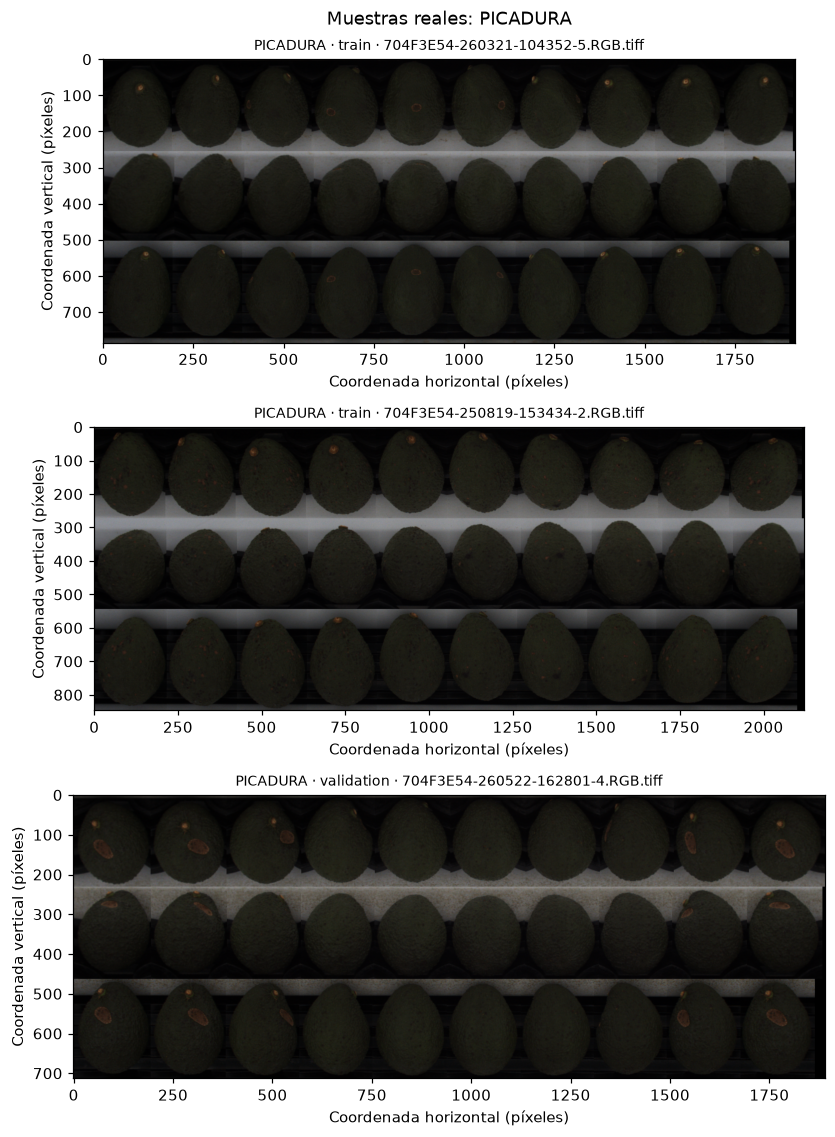

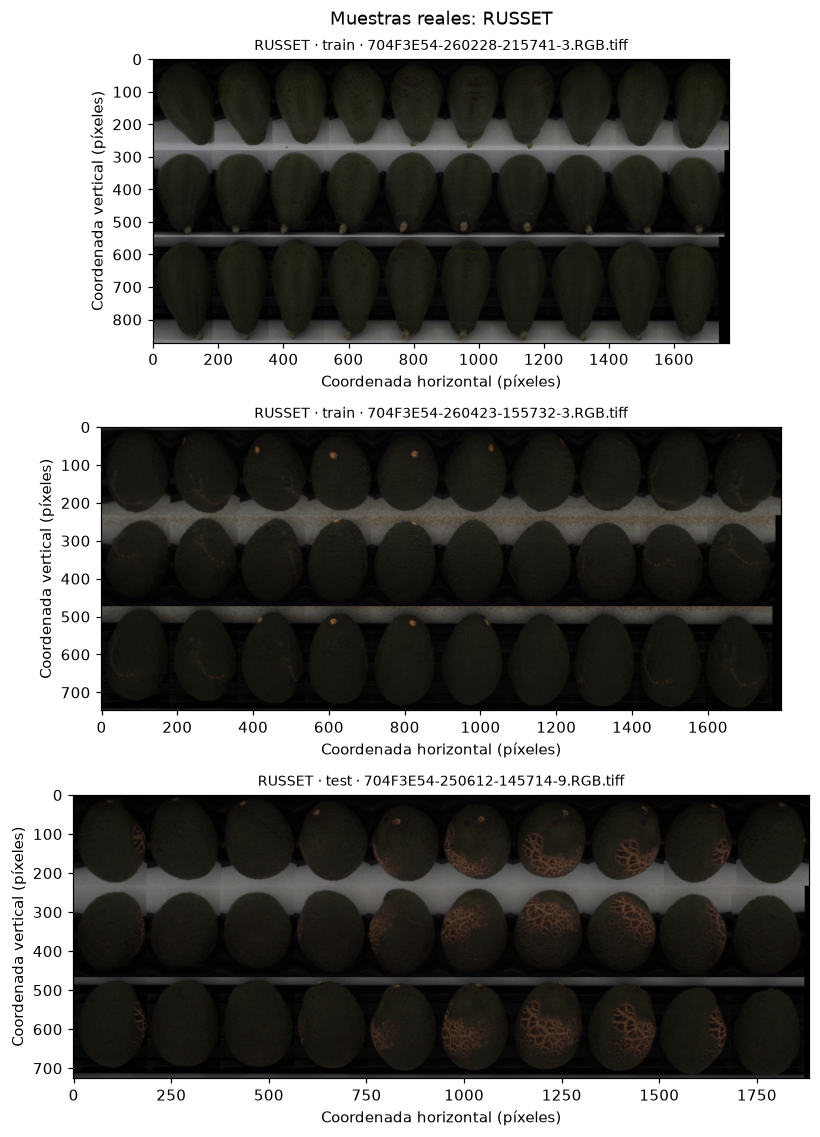

In [5]:
def mostrar_muestras(tabla, titulo, cantidad=3):
    seleccion = tabla.sample(n=min(cantidad, len(tabla)), random_state=SEMILLA)
    fig, axs = plt.subplots(len(seleccion), 1, figsize=(14, 3.5 * len(seleccion)), squeeze=False)
    for ax, r in zip(axs.ravel(), seleccion.itertuples()):
        with Image.open(DATASET / r.archivo) as im:
            ax.imshow(ImageOps.exif_transpose(im).convert('RGB'))
        ax.set_title(f'{r.clase} · {r.particion} · {Path(r.archivo).name}', fontsize=9)
        ax.set_xlabel('Coordenada horizontal (píxeles)'); ax.set_ylabel('Coordenada vertical (píxeles)'); ax.grid(False)
    fig.suptitle(titulo); plt.tight_layout(); plt.show()
for clase in clases:
    tabla = validas[validas.clase.eq(clase)]
    if not tabla.empty: mostrar_muestras(tabla, f'Muestras reales: {clase}')

### Observación visual de la ejecución inicial
En las seis muestras revisadas se observan tres franjas horizontales, vistas con distinta orientación y un fondo de rodillos/bandas con contraste entre zonas claras y oscuras. La superficie de las paltas se ve oscura y los defectos ocupan áreas pequeñas respecto a toda la imagen. En las muestras etiquetadas PICADURA hay marcas localizadas; en una muestra RUSSET del test se observa una región extensa con apariencia reticulada. Hay variación visual dentro de cada clase y diferencias de tamaño/posición. Estas observaciones describen las muestras revisadas, no validan diagnósticos ni todas las etiquetas. El conflicto de etiqueta detectado más adelante es un caso concreto que requiere revisión experta.

## 5. Intensidad, RGB y brillo aproximado
Cada observación de los gráficos representa el promedio de una imagen, no todos sus píxeles. Se compara por clase y por partición. Los contrastes pueden reflejar el fondo, la adquisición o la proporción de clases; no demuestran causalidad.

rojo               verde                azul               \
           mean median   std   mean median   std   mean median   std   
clase                                                                  
PICADURA  32.58  32.39  3.21  31.53  31.38  3.25  27.27  26.94  3.13   
RUSSET    33.31  32.94  3.59  32.18  31.52  4.02  27.60  26.90  3.40   

         intensidad              brillo               
               mean median   std   mean median   std  
clase                                                 
PICADURA      30.46  30.24  3.17  31.36  31.22  3.21  
RUSSET        31.03  30.55  3.63  32.00  31.51  3.80

rojo  verde   azul  intensidad  brillo
particion  clase                                            
test       PICADURA  34.25  33.10  28.70       32.02   32.94
           RUSSET    33.18  31.45  27.12       30.59   31.47
train      PICADURA  32.38  31.40  27.19       30.32   31.21
           RUSSET    33.22  32.21  27.65       31.03   31.99
validation PICADURA  31.85  30.59  26.25       29.56   30.47
           RUSSET    33.77  32.80  27.91       31.49   32.53

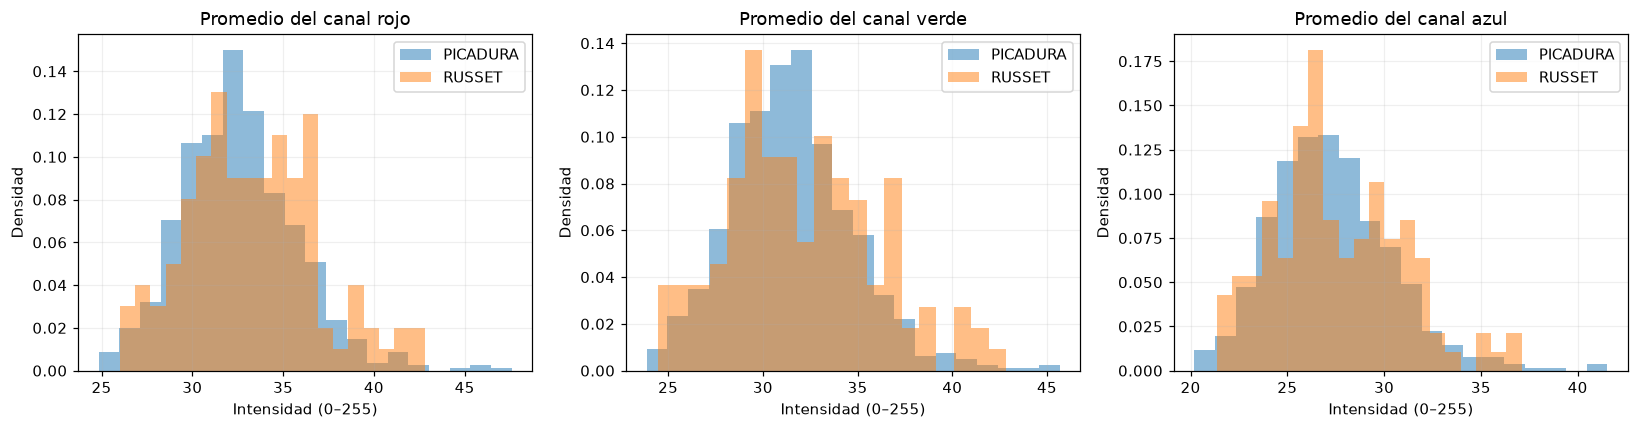

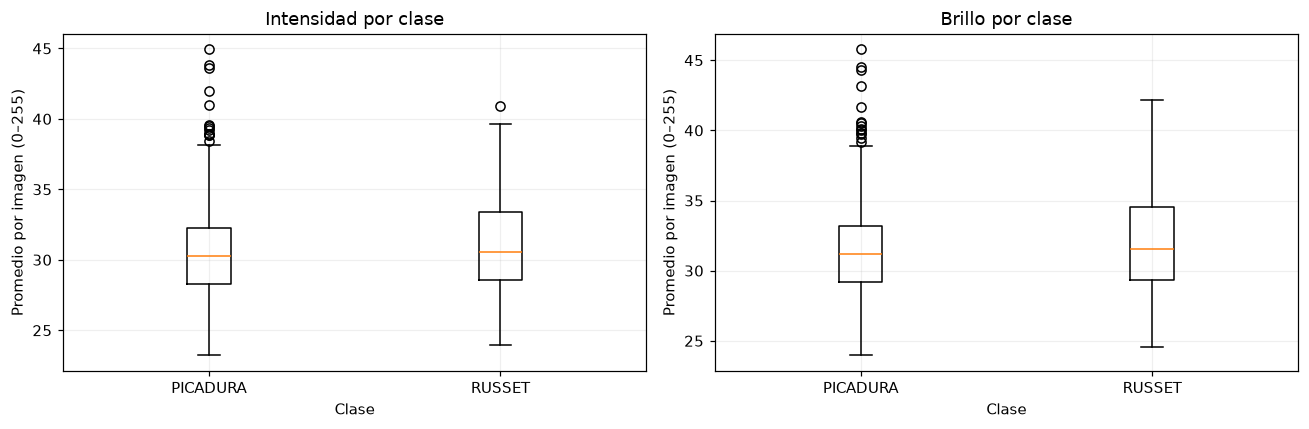

In [6]:
variables_color = ['rojo','verde','azul','intensidad','brillo']
display(validas.groupby('clase')[variables_color].agg(['mean','median','std']).round(2))
display(validas.groupby(['particion','clase'])[variables_color].mean().round(2))
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, canal in zip(axs, ['rojo','verde','azul']):
    for clase in clases:
        ax.hist(validas.loc[validas.clase.eq(clase), canal], bins=20, alpha=0.5, density=True, label=clase)
    ax.set(title=f'Promedio del canal {canal}', xlabel='Intensidad (0–255)', ylabel='Densidad'); ax.legend()
plt.tight_layout(); plt.show()
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, variable in zip(axs, ['intensidad','brillo']):
    ax.boxplot([validas.loc[validas.clase.eq(c),variable] for c in clases], tick_labels=clases)
    ax.set(title=f'{variable.capitalize()} por clase', xlabel='Clase', ylabel='Promedio por imagen (0–255)')
plt.tight_layout(); plt.show()

## 6. Duplicados exactos y posibles similitudes: data leakage
Se comparan todos los pares (viable para este dataset). Se reportan coincidencias dentro y entre particiones, incluidas etiquetas contradictorias. Un par puede coincidir tanto por archivo como por píxeles; las categorías no deben sumarse como imágenes únicas.

Un dHash con distancia ≤4/64 solo señala un candidato. En imágenes de varias cámaras puede confundir composiciones parecidas y perder coincidencias recortadas o rotadas. Ni hashes diferentes ni ausencia de candidatos garantizan independencia entre frutas: faltan identificadores de fruto/lote para comprobar agrupación.

**Copiar físicamente imágenes no equivale a augmentation dinámica.** Las copias no añaden observaciones independientes. La augmentation futura se aplica solo al entrenamiento, después de dividir por fruto/grupo, conservando validación y test independientes.

,tipo,archivo,clase,particion,archivo_coincidente,clase_coincidente,particion_coincidente,entre_particiones,etiquetas_distintas,distancia
0,bytes_exactos,test/RUSSET/704F3E54-250612-145719-5.RGB.tiff,RUSSET,test,train/PICADURA/704F3E54-250612-145719-5.RGB.tiff,PICADURA,train,True,True,None
1,bytes_exactos,train/PICADURA/704F3E54-250505-153013-0.RGB.tiff,PICADURA,train,validation/PICADURA/defecto.RGB.tiff,PICADURA,validation,True,False,None
2,pixeles_exactos,train/PICADURA/704F3E54-250505-153013-0.RGB.tiff,PICADURA,train,validation/PICADURA/defecto.RGB.tiff,PICADURA,validation,True,False,None
3,pixeles_exactos,test/RUSSET/704F3E54-250612-145719-5.RGB.tiff,RUSSET,test,train/PICADURA/704F3E54-250612-145719-5.RGB.tiff,PICADURA,train,True,True,None


Pares exactos únicos: 2; entre particiones: 2; candidatos visuales adicionales: 0


,tipo,particion,particion_coincidente,Pares
0,bytes_exactos,test,train,1
1,bytes_exactos,train,validation,1
2,pixeles_exactos,test,train,1
3,pixeles_exactos,train,validation,1


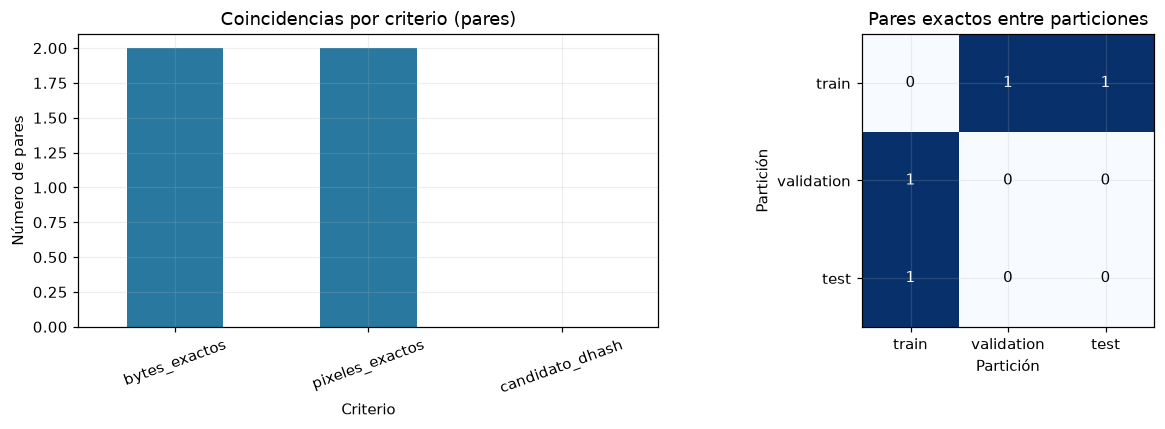

Matriz simétrica: no sumar ambas mitades; diagonal = pares internos.


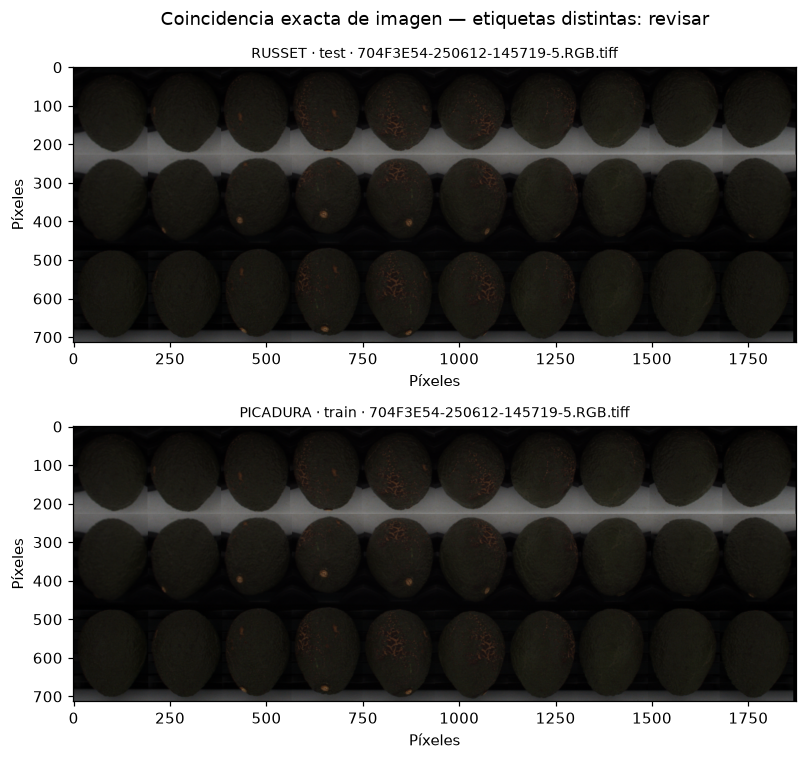

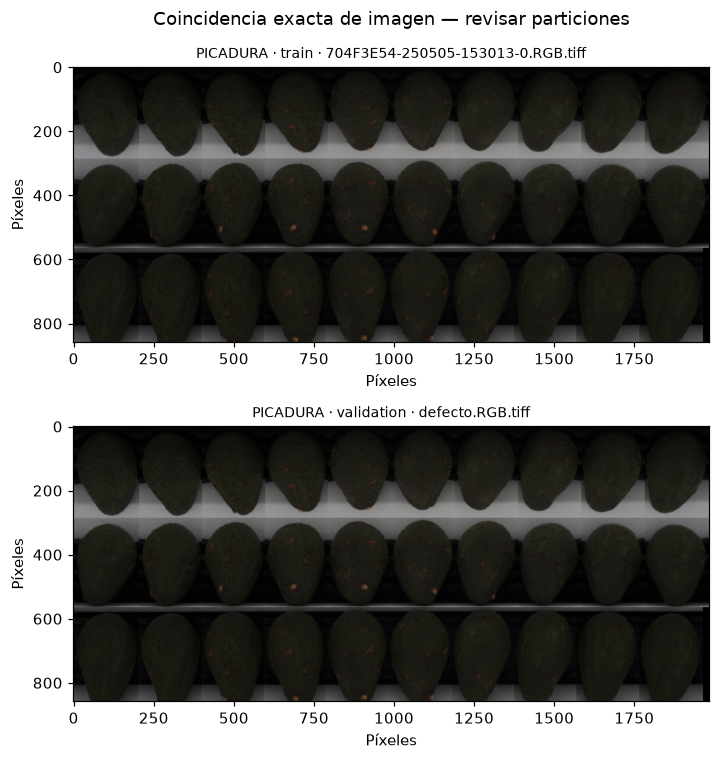

In [7]:
def registro_par(a, b, tipo, distancia=None):
    return dict(tipo=tipo, archivo=a['archivo'], clase=a['clase'], particion=a['particion'],
                archivo_coincidente=b['archivo'], clase_coincidente=b['clase'], particion_coincidente=b['particion'],
                entre_particiones=a['particion'] != b['particion'], etiquetas_distintas=a['clase'] != b['clase'], distancia=distancia)

pares = []
for columna, tipo, tabla in [('sha256','bytes_exactos',imagenes), ('sha_pixeles','pixeles_exactos',validas)]:
    for _, grupo in tabla.groupby(columna):
        for a, b in combinations(grupo.to_dict('records'), 2):
            pares.append(registro_par(a,b,tipo))
for a, b in combinations(validas.to_dict('records'), 2):
    if a['sha_pixeles'] == b['sha_pixeles']: continue
    distancia = (int(a['dhash'],16) ^ int(b['dhash'],16)).bit_count()
    if distancia <= UMBRAL_DHASH:
        pares.append(registro_par(a,b,'candidato_dhash',distancia))
columnas_pares = ['tipo','archivo','clase','particion','archivo_coincidente','clase_coincidente','particion_coincidente','entre_particiones','etiquetas_distintas','distancia']
duplicados = pd.DataFrame(pares, columns=columnas_pares)
exactos = duplicados[duplicados.tipo.isin(['bytes_exactos','pixeles_exactos'])].drop_duplicates(['archivo','archivo_coincidente'])
fugas = exactos[exactos.entre_particiones.eq(True)]
candidatos = duplicados[duplicados.tipo.eq('candidato_dhash')]
display(duplicados.head(20))
print(f'Pares exactos únicos: {len(exactos)}; entre particiones: {len(fugas)}; candidatos visuales adicionales: {len(candidatos)}')
display(duplicados.groupby(['tipo','particion','particion_coincidente']).size().rename('Pares').reset_index())
fig, axs = plt.subplots(1,2,figsize=(12,4))
tipos = ['bytes_exactos','pixeles_exactos','candidato_dhash']
duplicados.tipo.value_counts().reindex(tipos,fill_value=0).plot.bar(ax=axs[0], color='#2878a0')
axs[0].set(title='Coincidencias por criterio (pares)', xlabel='Criterio', ylabel='Número de pares'); axs[0].tick_params(axis='x',rotation=20)
matriz = pd.DataFrame(0,index=PARTICIONES,columns=PARTICIONES)
for r in exactos.itertuples():
    if r.particion in PARTICIONES and r.particion_coincidente in PARTICIONES:
        matriz.loc[r.particion,r.particion_coincidente] += 1
        if r.particion != r.particion_coincidente: matriz.loc[r.particion_coincidente,r.particion] += 1
axs[1].imshow(matriz,cmap='Blues'); axs[1].set(xticks=range(3),xticklabels=PARTICIONES,yticks=range(3),yticklabels=PARTICIONES,title='Pares exactos entre particiones',xlabel='Partición',ylabel='Partición')
for i in range(3):
    for j in range(3): axs[1].text(j,i,str(matriz.iloc[i,j]),ha='center',va='center',color='white' if matriz.iloc[i,j] > matriz.to_numpy().max()/2 else 'black')
plt.tight_layout(); plt.show()
print('Matriz simétrica: no sumar ambas mitades; diagonal = pares internos.')

# Revisión visual de coincidencias exactas y candidatos, priorizando conflictos de etiqueta.
revision = pd.concat([exactos, candidatos]).sort_values(['etiquetas_distintas','entre_particiones','distancia'], ascending=[False,False,True]).head(3)
for r in revision.itertuples():
    fig, axs = plt.subplots(2,1,figsize=(14,7))
    for ax, archivo, clase, particion in zip(axs,[r.archivo,r.archivo_coincidente],[r.clase,r.clase_coincidente],[r.particion,r.particion_coincidente]):
        with Image.open(DATASET / archivo) as im: ax.imshow(ImageOps.exif_transpose(im).convert('RGB'))
        ax.set_title(f'{clase} · {particion} · {Path(archivo).name}',fontsize=9); ax.grid(False)
        ax.set_xlabel('Píxeles'); ax.set_ylabel('Píxeles')
    titulo = f'Candidato visual, distancia dHash = {r.distancia:.0f}/64' if r.tipo == 'candidato_dhash' else 'Coincidencia exacta de imagen'
    fig.suptitle(titulo + (' — etiquetas distintas: revisar' if r.etiquetas_distintas else ' — revisar particiones'))
    plt.tight_layout(); plt.show()

## 7. Posibles diferencias de distribución entre particiones
Dataset estático: no se infiere drift temporal. Se comparan medias, dispersión, proporciones y diferencias de brillo dentro de cada clase. Son descripciones exploratorias; los duplicados reducen la independencia y pueden hacer engañosas las pruebas estadísticas.

brillo                   rojo                  verde          \
              mean  median    std    mean  median    std    mean  median   
particion                                                                  
train       31.319  31.127  3.293  32.491  32.289  3.237  31.512  31.278   
validation  30.810  30.320  3.414  32.163  31.594  3.448  30.954  30.481   
test        32.700  32.860  2.942  34.074  34.255  2.907  32.827  32.954   

                     azul                    ancho                      alto  \
              std    mean  median    std      mean  median      std     mean   
particion                                                                      
train       3.380  27.253  26.865  3.157  1960.841  1958.0  148.841  788.364   
validation  3.463  26.521  25.985  3.252  1883.047  1873.0  169.685  754.742   
test        3.006  28.439  28.270  2.846  1983.024  1991.0  158.928  790.787   

                          aspecto                
           median     std    mean median    std  
particion                                        
train       783.0  68.256   2.494  2.500  0.157  
validation  735.0  71.919   2.500  2.478  0.155  
test        790.0  65.532   2.512  2.517  0.144

clase,PICADURA,RUSSET
particion,,
train,31.21,31.99
validation,30.47,32.53
test,32.94,31.47


,Comparación,Máx. diferencia de clase (puntos porcentuales),Diferencia absoluta de brillo medio
0,train ↔ validation,2.992,0.509
1,train ↔ test,3.121,1.380
2,validation ↔ test,0.129,1.889


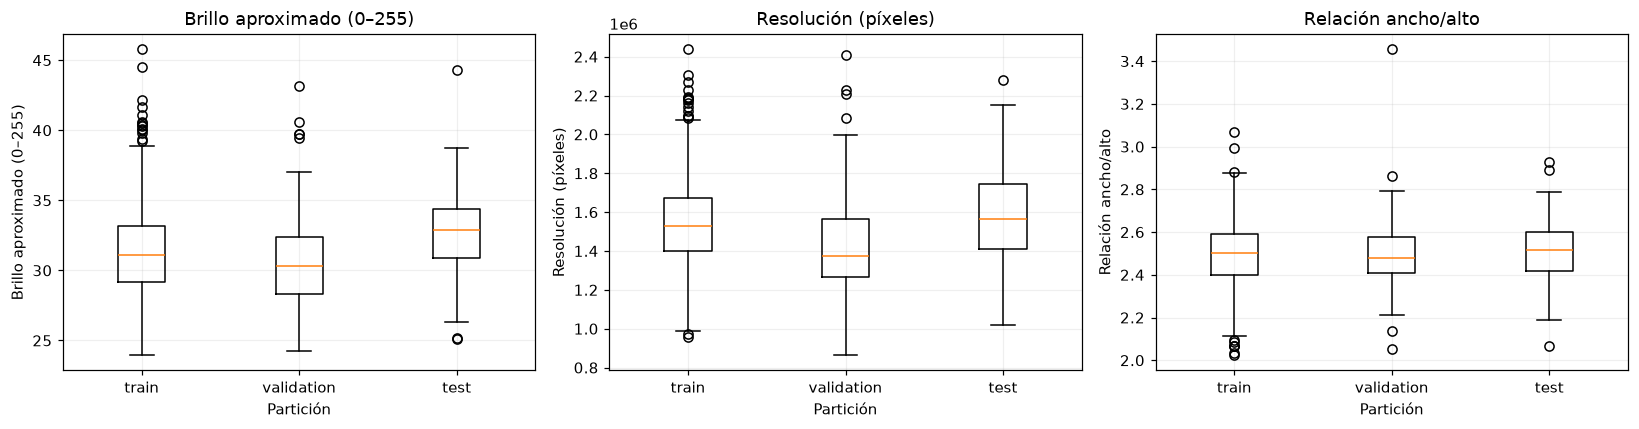

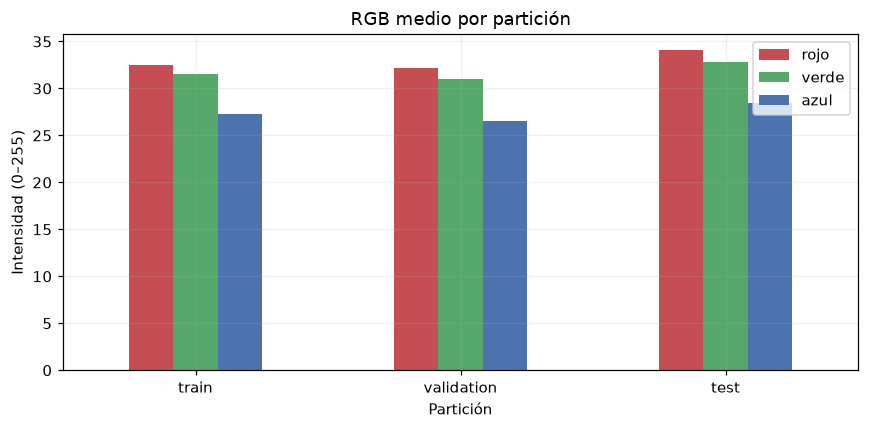

In [8]:
comparacion = validas.groupby('particion')[['brillo','rojo','verde','azul','ancho','alto','aspecto']].agg(['mean','median','std']).reindex(PARTICIONES)
display(comparacion.round(3))
brillo_clase = validas.pivot_table(index='particion',columns='clase',values='brillo',aggfunc='mean').reindex(PARTICIONES)
display(brillo_clase.round(2))
diferencias = []
for a,b in combinations(PARTICIONES,2):
    diferencias.append({'Comparación':f'{a} ↔ {b}',
        'Máx. diferencia de clase (puntos porcentuales)':float((proporciones.loc[a]-proporciones.loc[b]).abs().max()),
        'Diferencia absoluta de brillo medio':float(abs(validas.loc[validas.particion.eq(a),'brillo'].mean()-validas.loc[validas.particion.eq(b),'brillo'].mean()))})
tabla_diferencias = pd.DataFrame(diferencias); display(tabla_diferencias.round(3))
fig, axs = plt.subplots(1,3,figsize=(15,4))
for ax,col,titulo in zip(axs,['brillo','resolucion','aspecto'],['Brillo aproximado (0–255)','Resolución (píxeles)','Relación ancho/alto']):
    ax.boxplot([validas.loc[validas.particion.eq(s),col] for s in PARTICIONES],tick_labels=PARTICIONES)
    ax.set(title=titulo,xlabel='Partición',ylabel=titulo)
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(8,4))
validas.groupby('particion')[['rojo','verde','azul']].mean().reindex(PARTICIONES).plot.bar(ax=ax,color=['#c44e52','#55a868','#4c72b0'])
ax.set(title='RGB medio por partición',xlabel='Partición',ylabel='Intensidad (0–255)'); ax.tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.show()

## 8. Exportación y trazabilidad
Los CSV se guardan junto al notebook con prefijo `eda_`. El manifiesto contiene rutas relativas y hashes: permite comparar versiones del dataset. No se modifica ningún archivo de entrada. El hash global depende de las rutas y hashes de todos los archivos.

In [9]:
inventario.to_csv(SALIDA / 'eda_inventario.csv',index=False,encoding='utf-8-sig')
calidad.to_csv(SALIDA / 'eda_calidad.csv',index=False,encoding='utf-8-sig')
duplicados.to_csv(SALIDA / 'eda_duplicados.csv',index=False,encoding='utf-8-sig')
resumen.to_csv(SALIDA / 'eda_distribucion.csv',encoding='utf-8-sig')
firma = hashlib.sha256('\n'.join(inventario.archivo + ':' + inventario.sha256).encode()).hexdigest()
exceso_bytes = int(len(imagenes)-imagenes.sha256.nunique())
exceso_pixeles = int(len(validas)-validas.sha_pixeles.nunique())
resultado = dict(dataset=RUTA_RELATIVA,archivos=len(inventario),imagenes=len(imagenes),legibles=len(validas),clases=clases,
    conteos={s:{c:int(conteos.loc[s,c]) for c in clases} for s in PARTICIONES},
    razon_desbalance=razon,corruptas=int(imagenes.error.ne('').sum()),no_imagenes=int((~inventario.imagen).sum()),
    resoluciones=int(validas.groupby(['ancho','alto']).ngroups),copias_extra_bytes=exceso_bytes,copias_extra_pixeles=exceso_pixeles,
    pares_exactos=len(exactos),pares_exactos_entre_particiones=len(fugas),candidatos_dhash=len(candidatos),
    candidatos_dhash_entre_particiones=int(candidatos.entre_particiones.eq(True).sum()),
    pares_exactos_etiquetas_distintas=int(exactos.etiquetas_distintas.eq(True).sum()),
    incidencias_calidad=len(calidad),semilla=SEMILLA,umbral_dhash=UMBRAL_DHASH,sha256_dataset=firma,
    python=platform.python_version(),versiones=versiones)
(SALIDA / 'eda_resumen.json').write_text(json.dumps(resultado,ensure_ascii=False,indent=2),encoding='utf-8')
print(json.dumps(resultado,ensure_ascii=False,indent=2))

{
  "dataset": "../DATASET_PALTA",
  "archivos": 829,
  "imagenes": 829,
  "legibles": 829,
  "clases": [
    "PICADURA",
    "RUSSET"
  ],
  "conteos": {
    "train": {
      "PICADURA": 497,
      "RUSSET": 77
    },
    "validation": {
      "PICADURA": 107,
      "RUSSET": 21
    },
    "test": {
      "PICADURA": 106,
      "RUSSET": 21
    }
  },
  "razon_desbalance": 5.966386554621849,
  "corruptas": 0,
  "no_imagenes": 0,
  "resoluciones": 822,
  "copias_extra_bytes": 2,
  "copias_extra_pixeles": 2,
  "pares_exactos": 2,
  "pares_exactos_entre_particiones": 2,
  "candidatos_dhash": 0,
  "candidatos_dhash_entre_particiones": 0,
  "pares_exactos_etiquetas_distintas": 1,
  "incidencias_calidad": 37,
  "semilla": 42,
  "umbral_dhash": 4,
  "sha256_dataset": "97425b1ba327552b949961eeff19dd2d3f5d19b79ef67188252c28677f9540a1",
  "python": "3.12.14",
  "versiones": {
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
    "Pillow": "12.3.0",
    "nbformat": "5.11.1

## Conclusiones del análisis exploratorio
La siguiente celda redacta las conclusiones a partir de los cálculos ejecutados. Se actualizan si cambia el dataset.

In [10]:
riesgo = ('Hay coincidencias exactas entre particiones: existe contaminación de la evaluación y debe resolverse antes de entrenar.'
          if len(fugas) else 'No se detectaron coincidencias exactas entre particiones; esto no demuestra independencia entre frutos o lotes.')
texto = f"""- **Tamaño:** {len(imagenes)} imágenes, {len(clases)} clases; {len(validas)} legibles.
- **Distribución:** {', '.join(f'{c}: {int(por_clase[c])} ({por_clase[c]/len(imagenes)*100:.2f}%)' for c in clases)}.
- **Particiones:** {', '.join(f'{s}: {int(resumen.loc[s,"Total"])} ({resumen.loc[s,"Porcentaje"]:.2f}%)' for s in PARTICIONES)}.
- **Desbalance:** {razon:.2f}:1, descriptivamente {grado}; mayoría {por_clase.idxmax()}, minoría {por_clase.idxmin()}.
- **Duplicación:** {exceso_bytes} archivos adicionales respecto de hashes de bytes únicos; {exceso_pixeles} imágenes adicionales respecto de contenidos RGB únicos. Se encontraron {len(exactos)} pares exactos únicos, {len(fugas)} entre particiones, y {len(candidatos)} candidatos dHash adicionales.
- **Leakage:** {riesgo} Los candidatos visuales necesitan revisión humana; las vistas de una misma palta deben permanecer juntas.
- **Etiquetas:** {int(exactos.etiquetas_distintas.eq(True).sum())} pares exactos tienen clases distintas; si existen, requieren revisión experta.
- **Dimensiones:** {resultado['resoluciones']} combinaciones ancho×alto; ancho {validas.ancho.min():.0f}–{validas.ancho.max():.0f}, alto {validas.alto.min():.0f}–{validas.alto.max():.0f} píxeles.
- **Calidad:** {resultado['corruptas']} imágenes con errores, {resultado['no_imagenes']} archivos no reconocidos como imagen y {len(calidad)} incidencias reportadas. No se eliminó nada.
- **Distribuciones:** la mayor diferencia de proporción de clase es {tabla_diferencias.iloc[:,1].max():.2f} puntos porcentuales; la mayor diferencia de brillo medio es {tabla_diferencias.iloc[:,2].max():.2f}/255. Son diferencias entre particiones, no drift temporal demostrado.
- **Antes de entrenar:** revisar coincidencias y etiquetas; definir identificadores de fruta/lote y una separación por grupos; cuantificar clases sobre frutos independientes; conservar un test independiente. La procedencia de los datos y la validación experta de las etiquetas deben documentarse.
"""
display(Markdown(texto))

- **Tamaño:** 829 imágenes, 2 clases; 829 legibles.
- **Distribución:** PICADURA: 710 (85.65%), RUSSET: 119 (14.35%).
- **Particiones:** train: 574 (69.24%), validation: 128 (15.44%), test: 127 (15.32%).
- **Desbalance:** 5.97:1, descriptivamente marcado; mayoría PICADURA, minoría RUSSET.
- **Duplicación:** 2 archivos adicionales respecto de hashes de bytes únicos; 2 imágenes adicionales respecto de contenidos RGB únicos. Se encontraron 2 pares exactos únicos, 2 entre particiones, y 0 candidatos dHash adicionales.
- **Leakage:** Hay coincidencias exactas entre particiones: existe contaminación de la evaluación y debe resolverse antes de entrenar. Los candidatos visuales necesitan revisión humana; las vistas de una misma palta deben permanecer juntas.
- **Etiquetas:** 1 pares exactos tienen clases distintas; si existen, requieren revisión experta.
- **Dimensiones:** 822 combinaciones ancho×alto; ancho 1434–2429, alto 577–1068 píxeles.
- **Calidad:** 0 imágenes con errores, 0 archivos no reconocidos como imagen y 37 incidencias reportadas. No se eliminó nada.
- **Distribuciones:** la mayor diferencia de proporción de clase es 3.12 puntos porcentuales; la mayor diferencia de brillo medio es 1.89/255. Son diferencias entre particiones, no drift temporal demostrado.
- **Antes de entrenar:** revisar coincidencias y etiquetas; definir identificadores de fruta/lote y una separación por grupos; cuantificar clases sobre frutos independientes; conservar un test independiente. La procedencia de los datos y la validación experta de las etiquetas deben documentarse.


## Implicancias del EDA para el entrenamiento con ResNet50
- **Modelo principal:** ResNet50 mediante Transfer Learning. No se entrena en este notebook.
- **Resize:** aplicar en el pipeline, conservando originales. Definir la resolución después de considerar las dimensiones observadas y el tamaño de los defectos. Un resize cuadrado directo distorsiona imágenes multivista; evaluar padding que preserve aspecto o procesamiento por cámaras manteniendo el fruto como unidad. 224×224 es una referencia de entrada, no una resolución ya validada para este problema.
- **Normalización:** utilizar el preprocesamiento específico de la implementación y pesos elegidos. No combinar escalado arbitrario con otro preprocesamiento. Cualquier estadística aprendida se calcula exclusivamente sobre train.
- **Augmentation:** solo en train y aplicada dinámicamente. Validar que giros, recortes y cambios de color no destruyan las franjas de cámaras ni alteren la interpretación del defecto.
- **Balance:** considerar class weights, augmentation, undersampling u oversampling únicamente después de auditar duplicados y etiquetas. No se aplica ninguna estrategia automáticamente. Oversampling puede repetir observaciones; no incrementa el número de frutos independientes.
- **Duplicados y particiones:** resolver primero la contaminación observada y agrupar por fruto/lote antes de dividir. No mover archivos durante este EDA. Si se reconstruyen particiones, conservar un manifiesto y semilla.
- **Evaluación futura:** F1 por clase, macro-F1, balanced accuracy, precision/recall y matriz de confusión; fijar el protocolo antes de entrenar y no ajustar hiperparámetros con test.